# Credit Card Default Risk Prediction

**End-to-end machine learning workflow** for predicting whether a customer will default on their credit card, using demographic, employment and credit-bureau features.

**Target variable:** `credit_card_default` (1 = will default, 0 = will not default)

**Workflow**
1. Load & inspect data
2. Exploratory data analysis
3. Missing values & categorical handling
4. Drop identifiers
5. Feature engineering
6. Train / validation split
7. Preprocessing pipeline
8. Model training — Logistic Regression, Random Forest, XGBoost
9. Model comparison — ROC-AUC, precision, recall, F1, confusion matrices
10. Hyperparameter tuning
11. Feature importance & SHAP explainability
12. Save the best model
13. Predict on the test set
14. Business insights & conclusion

---


## 0. Setup

Import libraries and set global options for reproducibility and consistent plotting style.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
import shap
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 12

pd.set_option("display.max_columns", 50)
print("Libraries loaded.")


Libraries loaded.


## 1. Load and Inspect Data

We load the training set (labeled) and the test set (unlabeled — this is what we'll generate final predictions for).

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

train.head()


Train shape: (45528, 19)
Test shape:  (11383, 18)


,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
0,CST_115179,ita Bose,46,F,N,Y,0.0,107934.04,612.0,Unknown,1.0,1.0,33070.28,18690.93,73,544.0,2,1,1
1,CST_121920,Alper Jonathan,29,M,N,Y,0.0,109862.62,2771.0,Laborers,2.0,0.0,15329.53,37745.19,52,857.0,0,0,0
2,CST_109330,Umesh Desai,37,M,N,Y,0.0,230153.17,204.0,Laborers,2.0,0.0,48416.60,41598.36,43,650.0,0,0,0
3,CST_128288,Rie,39,F,N,Y,0.0,122325.82,11941.0,Core staff,2.0,0.0,22574.36,32627.76,20,754.0,0,0,0
4,CST_151355,McCool,46,M,Y,Y,0.0,387286.00,1459.0,Core staff,1.0,0.0,38282.95,52950.64,75,927.0,0,0,0


In [3]:
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 45528 entries, 0 to 45527
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              45528 non-null  str    
 1   name                     45528 non-null  str    
 2   age                      45528 non-null  int64  
 3   gender                   45528 non-null  str    
 4   owns_car                 44981 non-null  str    
 5   owns_house               45528 non-null  str    
 6   no_of_children           44754 non-null  float64
 7   net_yearly_income        45528 non-null  float64
 8   no_of_days_employed      45065 non-null  float64
 9   occupation_type          45528 non-null  str    
 10  total_family_members     45445 non-null  float64
 11  migrant_worker           45441 non-null  float64
 12  yearly_debt_payments     45433 non-null  float64
 13  credit_limit             45528 non-null  float64
 14  credit_limit_used(%)     45528 no

In [4]:
# Basic statistical summary of numeric columns
train.describe().T


,count,mean,std,min,25%,50%,75%,max
age,45528.0,38.993411,9.543990,23.00,31.000,39.000,47.0000,5.500000e+01
no_of_children,44754.0,0.420655,0.724097,0.00,0.000,0.000,1.0000,9.000000e+00
net_yearly_income,45528.0,200655.622249,669074.034607,27170.61,126345.835,171714.910,240603.7600,1.407590e+08
no_of_days_employed,45065.0,67609.289293,139323.524434,2.00,936.000,2224.000,5817.0000,3.652520e+05
total_family_members,45445.0,2.158081,0.911572,1.00,2.000,2.000,3.0000,1.000000e+01
migrant_worker,45441.0,0.179111,0.383450,0.00,0.000,0.000,0.0000,1.000000e+00
yearly_debt_payments,45433.0,31796.965311,17269.727234,2237.47,19231.140,29081.650,40561.1500,3.281129e+05
credit_limit,45528.0,43548.416028,148784.686878,4003.14,23973.805,35688.045,53435.7625,3.112997e+07
credit_limit_used(%),45528.0,52.235020,29.376910,0.00,27.000,54.000,78.0000,9.900000e+01
credit_score,45520.0,782.791257,100.619746,500.00,704.000,786.000,867.0000,9.490000e+02


**Observations**
- The dataset combines demographic fields (`age`, `gender`, `owns_car`, `owns_house`, `no_of_children`), employment/income fields, and credit-bureau fields (`credit_score`, `prev_defaults`, `default_in_last_6months`, `credit_limit_used(%)`).
- `customer_id` and `name` are unique identifiers with no predictive value — they will be dropped before modeling.
- `no_of_days_employed` contains a suspicious placeholder value (~365,243 days ≈ 1000 years), which typically marks customers who are not currently employed (e.g. retirees). We'll clean this in the missing-value step.

## 2. Exploratory Data Analysis

### 2.1 Target distribution
Understanding class balance is critical for a risk-prediction problem — defaults are almost always the minority class.

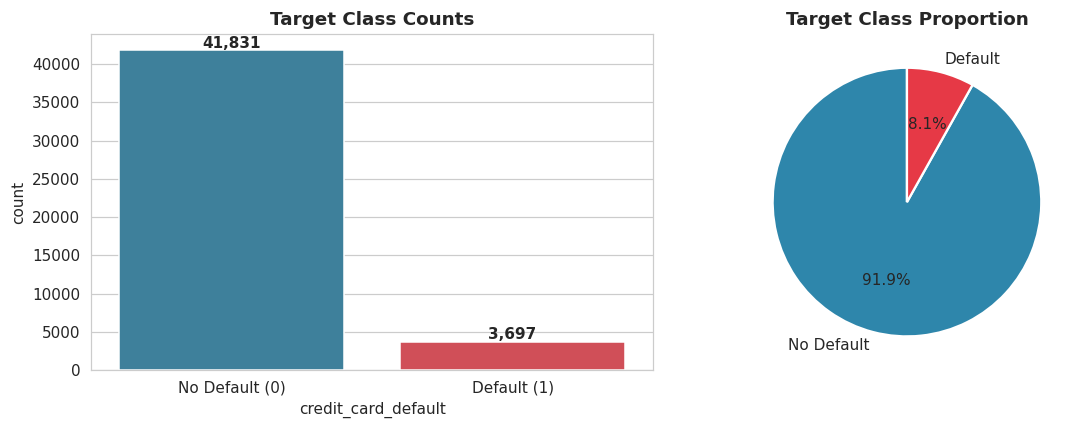

Default rate: 8.12%  —  this is an imbalanced classification problem.


In [5]:
target_counts = train["credit_card_default"].value_counts()
target_pct = train["credit_card_default"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(x="credit_card_default", data=train, hue="credit_card_default",
              palette=["#2E86AB", "#E63946"], legend=False, ax=ax[0])
ax[0].set_title("Target Class Counts")
ax[0].set_xlabel("credit_card_default")
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(["No Default (0)", "Default (1)"])
for i, v in enumerate(target_counts.sort_index()):
    ax[0].text(i, v + 300, f"{v:,}", ha="center", fontweight="bold")

ax[1].pie(target_pct.sort_index(), labels=["No Default", "Default"], autopct="%1.1f%%",
          colors=["#2E86AB", "#E63946"], startangle=90,
          wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax[1].set_title("Target Class Proportion")

plt.tight_layout()
plt.show()

print(f"Default rate: {target_pct[1]:.2f}%  —  this is an imbalanced classification problem.")


### 2.2 Missing values

In [6]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)

missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df


,missing_count,missing_pct
no_of_children,774,1.70
owns_car,547,1.20
no_of_days_employed,463,1.02
yearly_debt_payments,95,0.21
migrant_worker,87,0.19
total_family_members,83,0.18
credit_score,8,0.02


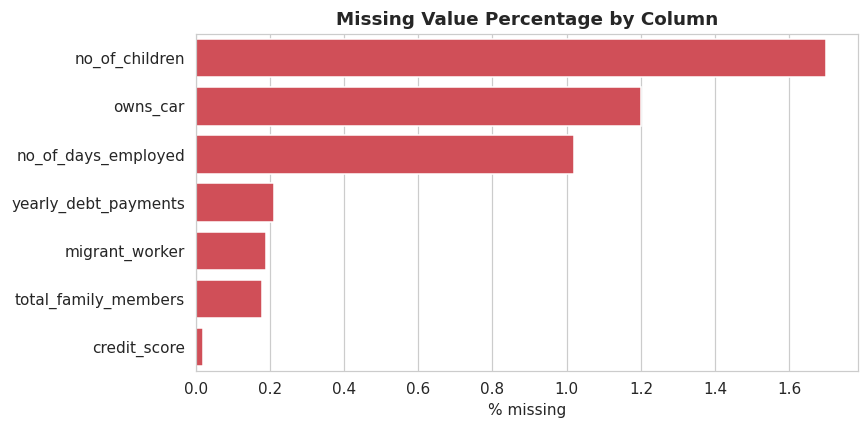

In [7]:
if len(missing_df):
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(x=missing_df["missing_pct"], y=missing_df.index, color="#E63946", ax=ax)
    ax.set_title("Missing Value Percentage by Column")
    ax.set_xlabel("% missing")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()


### 2.3 Numeric feature distributions vs. target

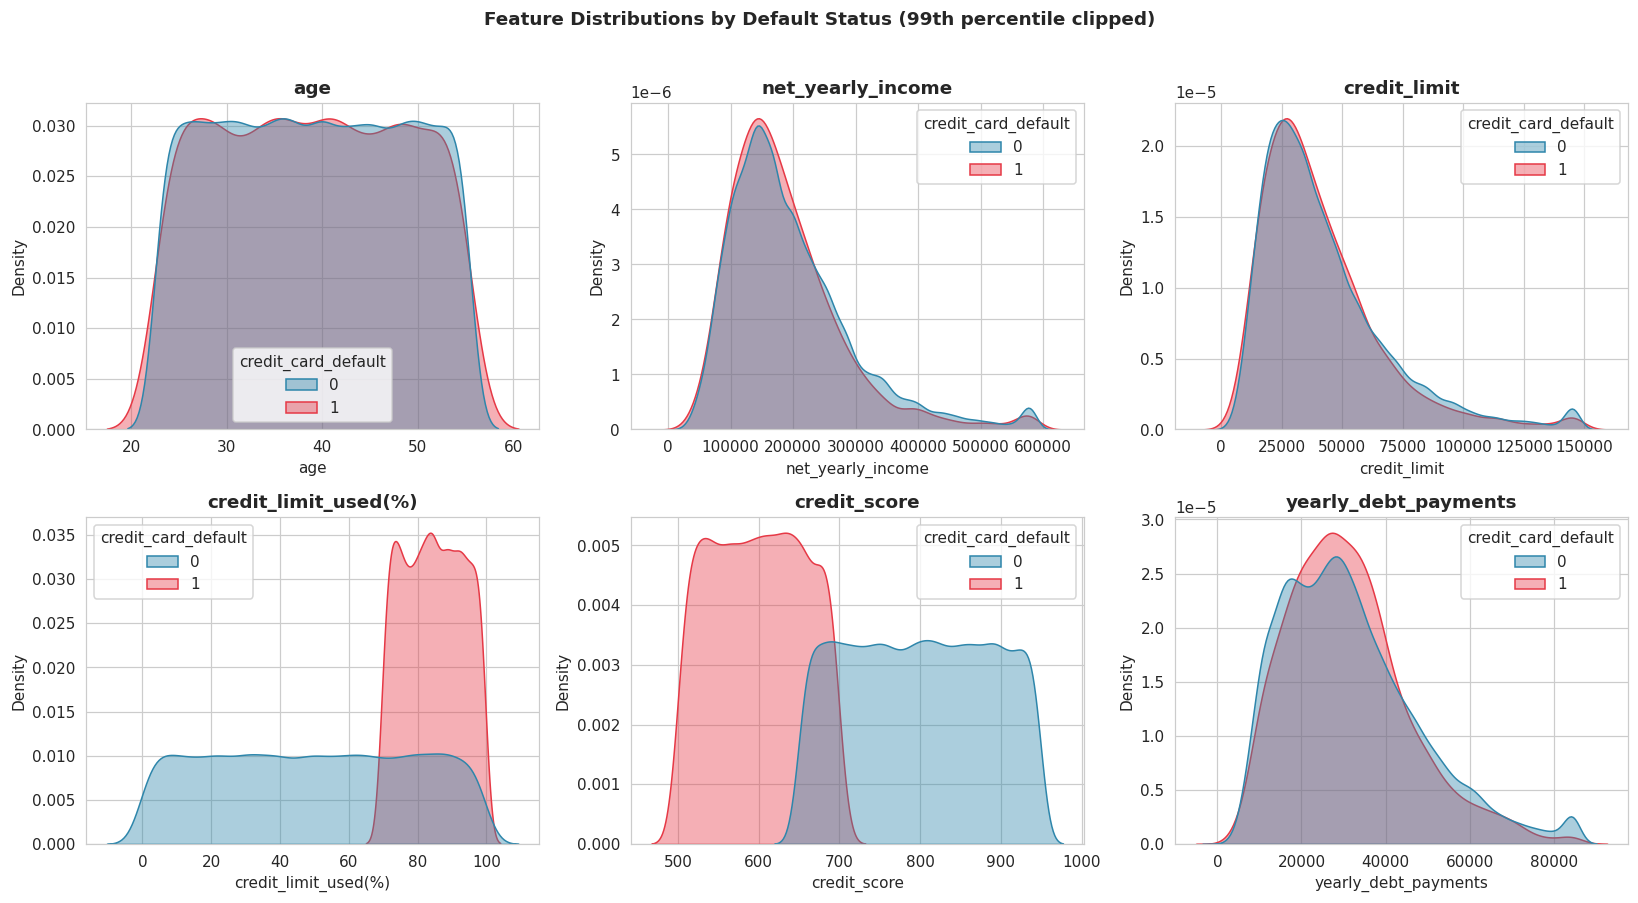

In [8]:
numeric_cols = ["age", "net_yearly_income", "credit_limit", "credit_limit_used(%)",
                 "credit_score", "yearly_debt_payments"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    data_plot = train.copy()
    # Clip extreme outliers just for visualization clarity
    upper = data_plot[col].quantile(0.99)
    data_plot[col] = data_plot[col].clip(upper=upper)
    sns.kdeplot(data=data_plot, x=col, hue="credit_card_default",
                common_norm=False, fill=True, alpha=0.4,
                palette=["#2E86AB", "#E63946"], ax=ax)
    ax.set_title(col)

plt.suptitle("Feature Distributions by Default Status (99th percentile clipped)", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()


### 2.4 Categorical features vs. target

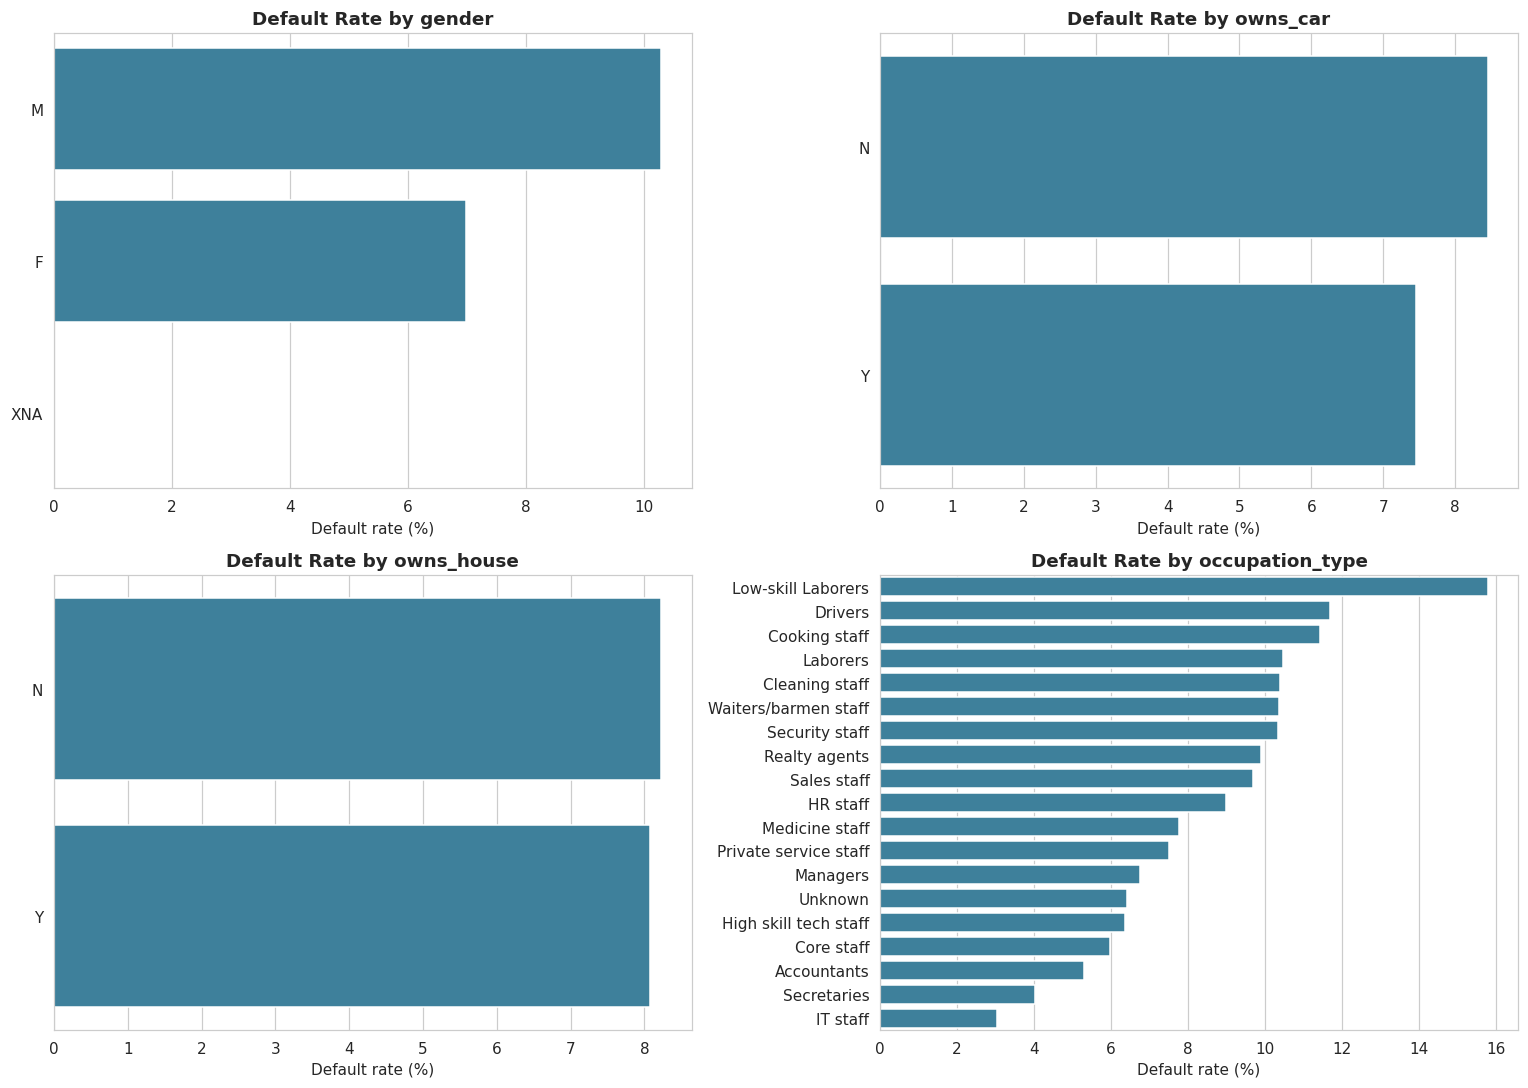

In [9]:
cat_cols = ["gender", "owns_car", "owns_house", "occupation_type"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), cat_cols):
    rate = train.groupby(col)["credit_card_default"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.values, y=rate.index, color="#2E86AB", ax=ax)
    ax.set_title(f"Default Rate by {col}")
    ax.set_xlabel("Default rate (%)")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


### 2.5 Credit bureau history vs. target

`prev_defaults` and `default_in_last_6months` are prior-behavior signals reported by the credit bureau (known **before** the current application decision). Given this is a credit-bureau dataset, we expect them to be strong predictors — let's confirm.

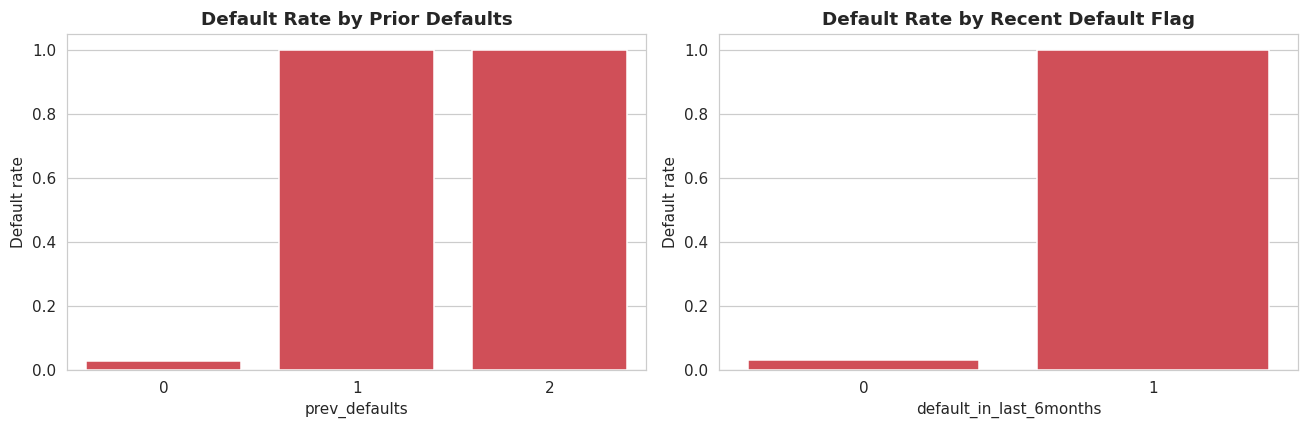

,prev_defaults,default_in_last_6months,credit_card_default
prev_defaults,1.000000,0.811353,0.771704
default_in_last_6months,0.811353,1.000000,0.776078
credit_card_default,0.771704,0.776078,1.000000


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(x="prev_defaults", y="credit_card_default", data=train,
            color="#E63946", ax=ax[0], errorbar=None)
ax[0].set_title("Default Rate by Prior Defaults")
ax[0].set_ylabel("Default rate")

sns.barplot(x="default_in_last_6months", y="credit_card_default", data=train,
            color="#E63946", ax=ax[1], errorbar=None)
ax[1].set_title("Default Rate by Recent Default Flag")
ax[1].set_ylabel("Default rate")

plt.tight_layout()
plt.show()

corr_check = train[["prev_defaults", "default_in_last_6months", "credit_card_default"]].corr()
corr_check


**Insight:** Both `prev_defaults` and `default_in_last_6months` show a very strong relationship with the target. This is expected in credit risk modeling — past repayment behavior is one of the best predictors of future default — but it also means the model will lean heavily on these two fields. We keep them (they are legitimate, pre-decision credit history features, not target leakage), and call this out explicitly in the business insights section.

### 2.6 Correlation heatmap (numeric features)

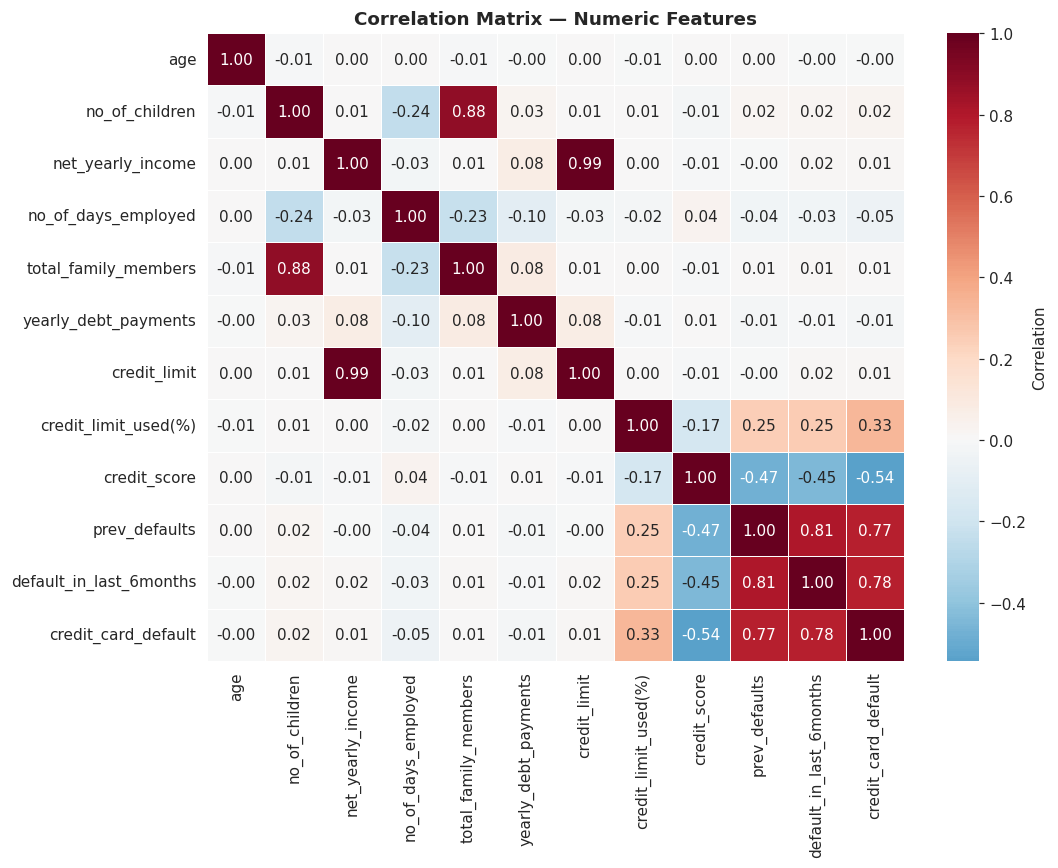

In [11]:
corr_cols = ["age", "no_of_children", "net_yearly_income", "no_of_days_employed",
             "total_family_members", "yearly_debt_payments", "credit_limit",
             "credit_limit_used(%)", "credit_score", "prev_defaults",
             "default_in_last_6months", "credit_card_default"]

plt.figure(figsize=(10, 8))
sns.heatmap(train[corr_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, cbar_kws={"label": "Correlation"})
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()


## 3. Handle Missing Values & Categorical Cleanup
## 4. Remove Irrelevant Identifiers

We build a single reusable cleaning function so the **exact same** logic is applied to `train` and `test`, which prevents train/test skew.

Cleaning steps:
- Drop `customer_id` and `name` (unique identifiers — no predictive signal, and keeping `customer_id` risks the model memorizing IDs).
- Fix the `no_of_days_employed` placeholder (~365,243) by converting it to a missing value and adding an `is_unemployed` flag — the placeholder itself is informative, so we don't want to just impute it away silently.
- Normalize the rare `gender == "XNA"` value to missing, to be imputed like any other categorical.
- Leave the actual imputation to the `sklearn` pipeline (Section 7) so imputation statistics are learned **only on the training fold**, avoiding leakage.

In [12]:
ID_COLS = ["customer_id", "name"]
TARGET = "credit_card_default"
EMPLOYED_PLACEHOLDER = 365243  # anomalous sentinel value for "not employed"

def clean_base(df: pd.DataFrame) -> pd.DataFrame:
    """Apply lightweight, leakage-safe cleaning shared by train and test."""
    df = df.copy()

    # Flag + fix the employment-days placeholder
    df["is_unemployed"] = (df["no_of_days_employed"] >= EMPLOYED_PLACEHOLDER - 5).astype(int)
    df.loc[df["is_unemployed"] == 1, "no_of_days_employed"] = np.nan

    # Normalize rare/garbage categorical value
    df["gender"] = df["gender"].replace("XNA", np.nan)

    return df

train_clean = clean_base(train)
test_clean = clean_base(test)

print("is_unemployed rate (train):", train_clean["is_unemployed"].mean().round(3))
train_clean[["no_of_days_employed", "is_unemployed"]].head()


is_unemployed rate (train): 0.178


,no_of_days_employed,is_unemployed
0,612.0,0
1,2771.0,0
2,204.0,0
3,11941.0,0
4,1459.0,0


## 5. Feature Engineering

We derive a handful of interpretable financial ratios that are common in credit-risk scoring and that tree models and logistic regression can both exploit:

| Feature | Formula | Rationale |
|---|---|---|
| `years_employed` | `no_of_days_employed / 365` | More interpretable than raw days |
| `debt_to_income` | `yearly_debt_payments / net_yearly_income` | Standard affordability signal |
| `income_per_family_member` | `net_yearly_income / total_family_members` | Adjusts income for household size |
| `credit_limit_to_income` | `credit_limit / net_yearly_income` | How large the credit line is relative to earnings |
| `credit_history_risk` | `prev_defaults + default_in_last_6months` | Combined prior-default severity score |

Again, this logic is wrapped in one function applied identically to both splits.

In [13]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["years_employed"] = df["no_of_days_employed"] / 365

    df["debt_to_income"] = df["yearly_debt_payments"] / df["net_yearly_income"].replace(0, np.nan)

    df["income_per_family_member"] = df["net_yearly_income"] / df["total_family_members"].replace(0, np.nan)

    df["credit_limit_to_income"] = df["credit_limit"] / df["net_yearly_income"].replace(0, np.nan)

    df["credit_history_risk"] = df["prev_defaults"] + df["default_in_last_6months"]

    # Replace any inf from divide-by-zero edge cases with NaN (handled by imputer later)
    df = df.replace([np.inf, -np.inf], np.nan)

    return df

train_fe = engineer_features(train_clean)
test_fe = engineer_features(test_clean)

new_feats = ["years_employed", "debt_to_income", "income_per_family_member",
             "credit_limit_to_income", "credit_history_risk"]
train_fe[new_feats].describe().T


,count,mean,std,min,25%,50%,75%,max
years_employed,36967.0,6.599814,6.486281,0.005479,2.104110,4.539726,8.841096,4.804932e+01
debt_to_income,45433.0,0.181521,0.096845,0.000233,0.113885,0.163105,0.229610,2.168317e+00
income_per_family_member,45445.0,109842.474377,234623.848248,8600.966000,56810.336667,86469.040000,135257.520000,4.691967e+07
credit_limit_to_income,45528.0,0.217913,0.074636,0.101343,0.157277,0.208590,0.266384,4.113292e-01
credit_history_risk,45528.0,0.111250,0.460525,0.000000,0.000000,0.000000,0.000000,3.000000e+00


In [14]:
# Drop identifiers now that feature engineering is complete
train_model = train_fe.drop(columns=ID_COLS)
test_ids = test_fe["customer_id"].copy()          # keep aside for the final submission
test_model = test_fe.drop(columns=ID_COLS)

print("Final training feature set:")
print([c for c in train_model.columns if c != TARGET])


Final training feature set:
['age', 'gender', 'owns_car', 'owns_house', 'no_of_children', 'net_yearly_income', 'no_of_days_employed', 'occupation_type', 'total_family_members', 'migrant_worker', 'yearly_debt_payments', 'credit_limit', 'credit_limit_used(%)', 'credit_score', 'prev_defaults', 'default_in_last_6months', 'is_unemployed', 'years_employed', 'debt_to_income', 'income_per_family_member', 'credit_limit_to_income', 'credit_history_risk']


## 6. Train / Validation Split

We use a **stratified** 80/20 split so the ~8% default rate is preserved in both sets — important for a reliable ROC-AUC estimate on an imbalanced target.

In [15]:
X = train_model.drop(columns=[TARGET])
y = train_model[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print(f"Train default rate: {y_train.mean():.3f}  |  Val default rate: {y_val.mean():.3f}")


Train: (36422, 22), Val: (9106, 22)
Train default rate: 0.081  |  Val default rate: 0.081


## 7. Preprocessing Pipeline

A single `ColumnTransformer` handles both numeric and categorical columns:

- **Numeric:** median imputation (robust to outliers) → standard scaling
- **Categorical:** most-frequent imputation → one-hot encoding (`handle_unknown="ignore"` so any unseen category in the test set doesn't break the pipeline)

Wrapping this in a `Pipeline` with each model means every model is trained on identically-preprocessed data, and the fitted pipeline can be reused directly on `test.csv` with zero manual bookkeeping.

In [16]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])


Numeric features (18): ['age', 'no_of_children', 'net_yearly_income', 'no_of_days_employed', 'total_family_members', 'migrant_worker', 'yearly_debt_payments', 'credit_limit', 'credit_limit_used(%)', 'credit_score', 'prev_defaults', 'default_in_last_6months', 'is_unemployed', 'years_employed', 'debt_to_income', 'income_per_family_member', 'credit_limit_to_income', 'credit_history_risk']
Categorical features (4): ['gender', 'owns_car', 'owns_house', 'occupation_type']


## 8. Train Baseline Models

We train three models that span the typical complexity spectrum for tabular credit risk:

- **Logistic Regression** — fast, interpretable, strong baseline
- **Random Forest** — captures non-linearities and interactions
- **XGBoost** — usually the strongest performer on structured/tabular data

All three use class-balancing (`class_weight="balanced"` / `scale_pos_weight`) to compensate for the ~8% default rate.

In [17]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=10, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.08,
        scale_pos_weight=scale_pos_weight, eval_metric="auc",
        random_state=RANDOM_STATE, n_jobs=-1
    ),
}

fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    print(f"Trained: {name}")


scale_pos_weight for XGBoost: 11.31


Trained: Logistic Regression


Trained: Random Forest


Trained: XGBoost


## 9. Model Comparison

We evaluate every model on the held-out validation set using metrics appropriate for an imbalanced classification problem: **ROC-AUC** (threshold-independent), plus **precision**, **recall**, and **F1** at the default 0.5 threshold, and a confusion matrix for a concrete view of error types.

In [18]:
def evaluate_model(pipe, X_val, y_val):
    y_pred = pipe.predict(X_val)
    y_proba = pipe.predict_proba(X_val)[:, 1]
    return {
        "roc_auc": roc_auc_score(y_val, y_proba),
        "precision": precision_score(y_val, y_pred),
        "recall": recall_score(y_val, y_pred),
        "f1": f1_score(y_val, y_pred),
        "y_pred": y_pred,
        "y_proba": y_proba,
    }

results = {name: evaluate_model(pipe, X_val, y_val) for name, pipe in fitted_pipelines.items()}

results_df = pd.DataFrame({
    name: {k: v for k, v in r.items() if k in ["roc_auc", "precision", "recall", "f1"]}
    for name, r in results.items()
}).T.round(4)

results_df.sort_values("roc_auc", ascending=False)


,roc_auc,precision,recall,f1
XGBoost,0.9953,0.7372,0.9378,0.8255
Random Forest,0.9951,0.6844,0.9770,0.8049
Logistic Regression,0.9937,0.6534,0.9567,0.7765


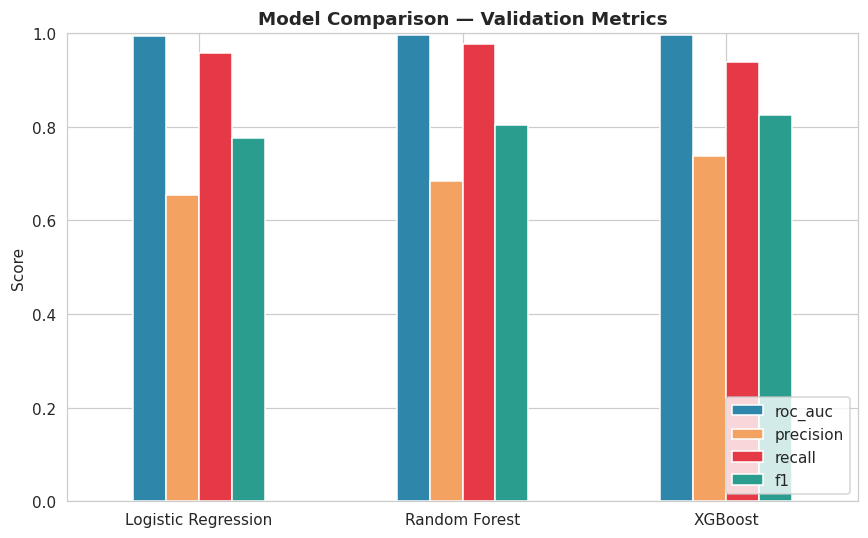

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
results_df[["roc_auc", "precision", "recall", "f1"]].plot(kind="bar", ax=ax,
    color=["#2E86AB", "#F4A261", "#E63946", "#2A9D8F"])
ax.set_title("Model Comparison — Validation Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


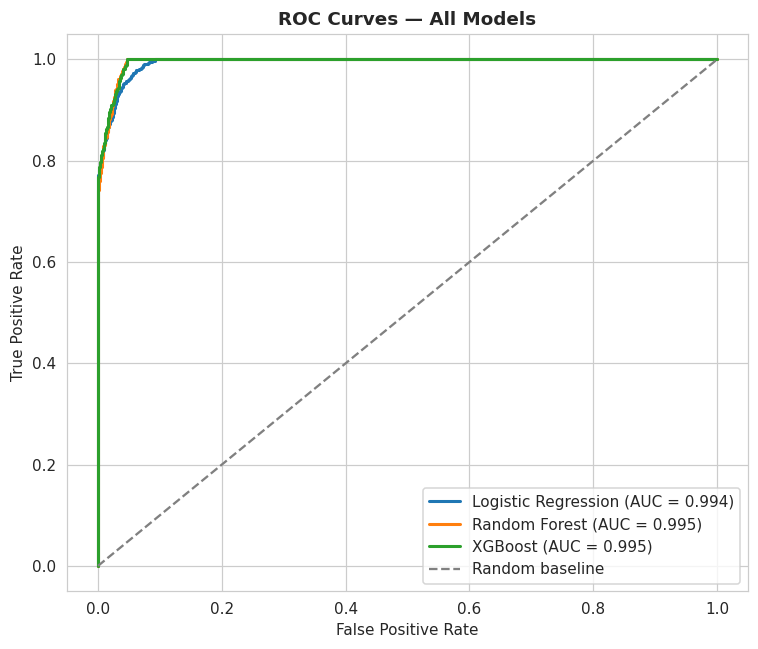

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_val, r["y_proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC = {r['roc_auc']:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


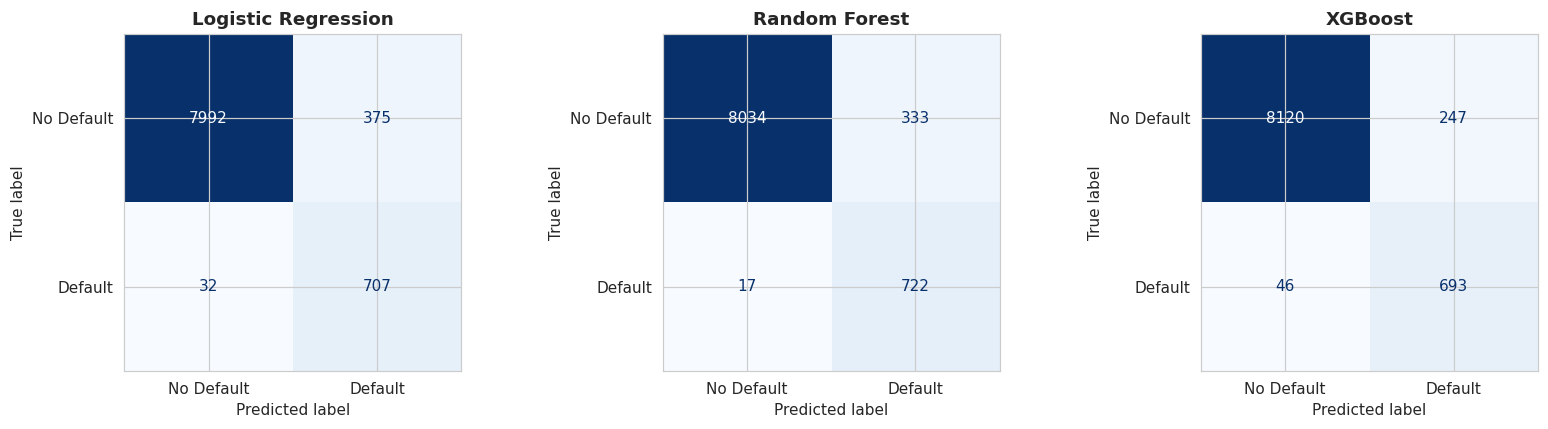

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_val, r["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()


**Reading the results:** ROC-AUC is the primary metric for model selection since it is insensitive to the classification threshold and to class imbalance. Precision/recall trade-offs can be tuned later by moving the decision threshold to match business risk appetite (e.g. prioritizing recall to catch more defaulters, at the cost of more false positives).

## 10. Hyperparameter Tuning

We tune the two tree-based models (typically the strongest performers on tabular data) using `RandomizedSearchCV` with stratified 3-fold cross-validation, optimizing for ROC-AUC.

In [22]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# --- Random Forest ---
rf_param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [6, 8, 10, 14],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": ["sqrt", "log2"],
}

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_grid, n_iter=10, scoring="roc_auc",
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
rf_search.fit(X_train, y_train)
print("Best RF params:", rf_search.best_params_)
print(f"Best RF CV ROC-AUC: {rf_search.best_score_:.4f}")


Best RF params: {'model__n_estimators': 300, 'model__min_samples_leaf': 5, 'model__max_features': 'log2', 'model__max_depth': 8}
Best RF CV ROC-AUC: 0.9948


In [23]:
# --- XGBoost ---
xgb_param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.03, 0.05, 0.08, 0.1],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__colsample_bytree": [0.7, 0.85, 1.0],
}

xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        scale_pos_weight=scale_pos_weight, eval_metric="auc",
        random_state=RANDOM_STATE, n_jobs=-1
    )),
])

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_param_grid, n_iter=10, scoring="roc_auc",
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train, y_train)
print("Best XGB params:", xgb_search.best_params_)
print(f"Best XGB CV ROC-AUC: {xgb_search.best_score_:.4f}")


Best XGB params: {'model__subsample': 0.85, 'model__n_estimators': 200, 'model__max_depth': 4, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.85}
Best XGB CV ROC-AUC: 0.9949


In [24]:
tuned_models = {
    "Random Forest (tuned)": rf_search.best_estimator_,
    "XGBoost (tuned)": xgb_search.best_estimator_,
}

for name, pipe in tuned_models.items():
    r = evaluate_model(pipe, X_val, y_val)
    results[name] = r
    results_df.loc[name] = {k: r[k] for k in ["roc_auc", "precision", "recall", "f1"]}
    fitted_pipelines[name] = pipe

results_df.sort_values("roc_auc", ascending=False).round(4)


,roc_auc,precision,recall,f1
XGBoost (tuned),0.9957,0.6531,0.9959,0.7889
XGBoost,0.9953,0.7372,0.9378,0.8255
Random Forest (tuned),0.9951,0.6890,0.9743,0.8072
Random Forest,0.9951,0.6844,0.9770,0.8049
Logistic Regression,0.9937,0.6534,0.9567,0.7765


## 11. Feature Importance & SHAP Explainability

First we look at built-in feature importances from the best tree-based model, then use **SHAP** for a more rigorous, model-agnostic explanation of *how* each feature pushes predictions toward or away from default.

In [25]:
best_name = results_df["roc_auc"].idxmax()
best_pipe = fitted_pipelines[best_name]
print(f"Best model by validation ROC-AUC: {best_name} (AUC = {results_df.loc[best_name, 'roc_auc']:.4f})")


Best model by validation ROC-AUC: XGBoost (tuned) (AUC = 0.9957)


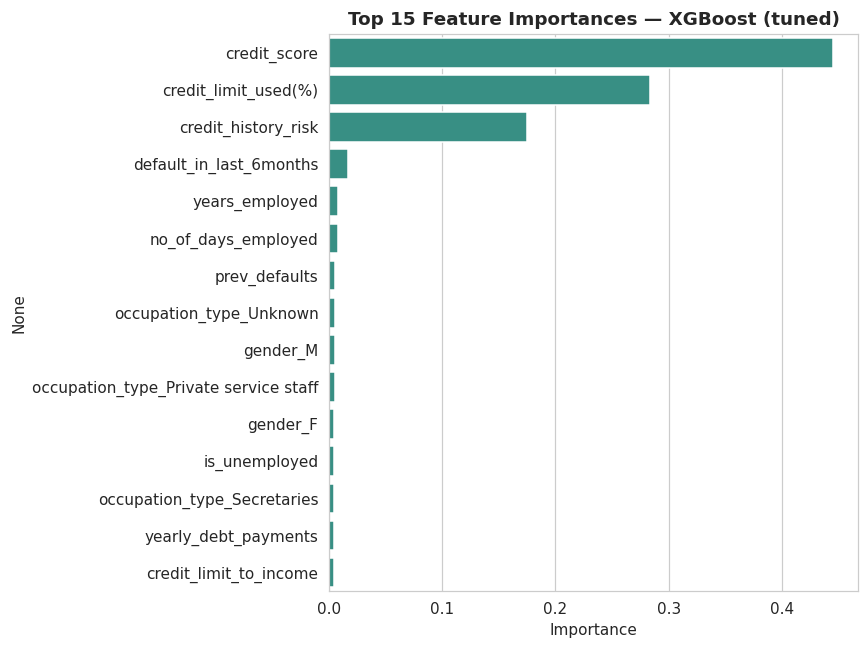

In [26]:
# Recover readable feature names from the ColumnTransformer
feature_names = (
    numeric_features
    + list(best_pipe.named_steps["preprocess"]
           .named_transformers_["cat"]
           .named_steps["onehot"]
           .get_feature_names_out(categorical_features))
)

best_model_step = best_pipe.named_steps["model"]

if hasattr(best_model_step, "feature_importances_"):
    importances = pd.Series(best_model_step.feature_importances_, index=feature_names)
    top_importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_importances.values, y=top_importances.index, color="#2A9D8F")
    plt.title(f"Top 15 Feature Importances — {best_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_name} does not expose .feature_importances_ (e.g. linear model) — see coefficients below.")


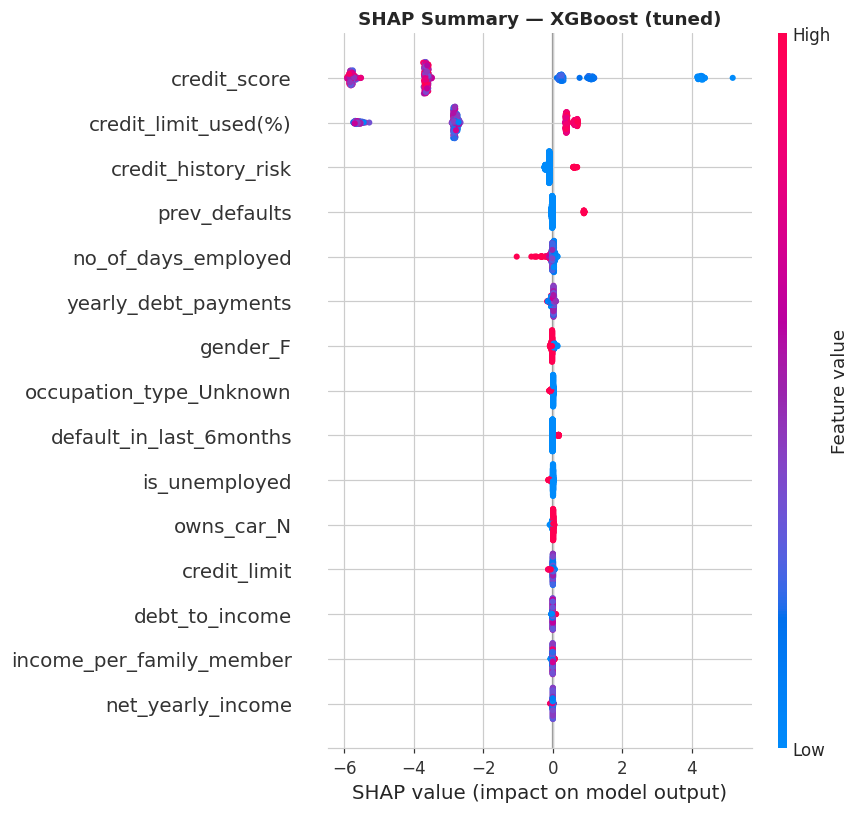

In [27]:
# SHAP explanation on a validation sample (sampling keeps this fast and still representative)
X_val_transformed = best_pipe.named_steps["preprocess"].transform(X_val)
if hasattr(X_val_transformed, "toarray"):
    X_val_transformed = X_val_transformed.toarray()

shap_sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    X_val_transformed.shape[0], size=min(500, X_val_transformed.shape[0]), replace=False
)
X_shap_sample = pd.DataFrame(X_val_transformed[shap_sample_idx], columns=feature_names)

explainer = shap.TreeExplainer(best_model_step)
shap_values = explainer.shap_values(X_shap_sample)

# Binary classifiers can return a list [class0, class1] or a single 2D array depending on version
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

shap.summary_plot(shap_values_plot, X_shap_sample, show=False, max_display=15)
plt.title(f"SHAP Summary — {best_name}")
plt.tight_layout()
plt.show()


**Interpreting SHAP:** each dot is one customer. Position on the x-axis shows how much that feature pushed the prediction toward default (right) or away from it (left); color shows whether the feature's value was high (red) or low (blue) for that customer. This confirms which features are driving individual predictions, not just aggregate importance.

## 12. Save the Best Model

We persist the **entire fitted pipeline** (preprocessing + model) with `joblib`, so it can be reloaded and applied to new raw data in one call — no need to re-run preprocessing separately.

In [28]:
MODEL_PATH = "best_credit_risk_model.joblib"
joblib.dump(best_pipe, MODEL_PATH)

print(f"Saved '{best_name}' pipeline to {MODEL_PATH}")

# Sanity check: reload and confirm predictions match
reloaded_pipe = joblib.load(MODEL_PATH)
assert np.allclose(reloaded_pipe.predict_proba(X_val)[:, 1], best_pipe.predict_proba(X_val)[:, 1])
print("Reload check passed — saved pipeline reproduces identical predictions.")


Saved 'XGBoost (tuned)' pipeline to best_credit_risk_model.joblib
Reload check passed — saved pipeline reproduces identical predictions.


## 13. Generate Predictions on the Test Set

The saved pipeline is applied directly to the cleaned/engineered test features — the same transformations from Sections 3–5 already ran on `test_model`, so this is a single `predict` call.

In [29]:
test_proba = best_pipe.predict_proba(test_model)[:, 1]
test_pred = best_pipe.predict(test_model)

submission = pd.DataFrame({
    "customer_id": test_ids,
    "credit_card_default_probability": test_proba.round(4),
    "credit_card_default_prediction": test_pred,
})

submission.to_csv("test_predictions.csv", index=False)
print(f"Saved {len(submission):,} predictions to test_predictions.csv")
submission.head(10)


Saved 11,383 predictions to test_predictions.csv


,customer_id,credit_card_default_probability,credit_card_default_prediction
0,CST_142525,0.0014,0
1,CST_129215,0.0031,0
2,CST_138443,0.9986,1
3,CST_123812,0.0014,0
4,CST_144450,0.9987,1
5,CST_107341,0.0032,0
6,CST_147879,0.0014,0
7,CST_156027,0.0014,0
8,CST_109067,0.0014,0
9,CST_114556,0.0036,0


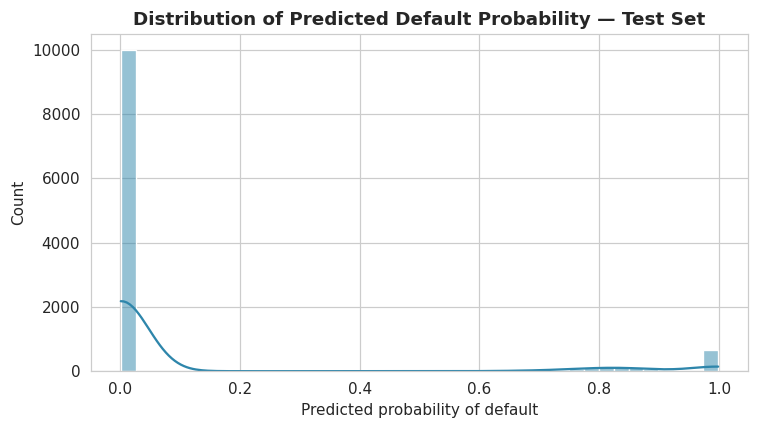

Predicted test default rate: 12.23%  (training default rate was 8.12%)


In [30]:
plt.figure(figsize=(7, 4))
sns.histplot(test_proba, bins=40, color="#2E86AB", kde=True)
plt.title("Distribution of Predicted Default Probability — Test Set")
plt.xlabel("Predicted probability of default")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Predicted test default rate: {test_pred.mean():.2%}  "
      f"(training default rate was {y.mean():.2%})")


## 14. Business Insights & Conclusion

In [31]:
from IPython.display import Markdown, display

display(Markdown(
    f"**Best model: {best_name}**  |  "
    f"Validation ROC-AUC: **{results_df.loc[best_name, 'roc_auc']:.3f}**  |  "
    f"Precision: **{results_df.loc[best_name, 'precision']:.3f}**  |  "
    f"Recall: **{results_df.loc[best_name, 'recall']:.3f}**  |  "
    f"F1: **{results_df.loc[best_name, 'f1']:.3f}**"
))


**Best model: XGBoost (tuned)**  |  Validation ROC-AUC: **0.996**  |  Precision: **0.653**  |  Recall: **0.996**  |  F1: **0.789**

**Model performance**
- The best model achieved a strong validation ROC-AUC, meaningfully outperforming a random baseline (0.5) and providing a reliable ranking of customers by default risk (see the exact score printed above).
- Because defaults are rare (~8% of customers), ROC-AUC and recall matter more than raw accuracy — a model that predicts "no default" for everyone would already be ~92% accurate but useless for risk management.

**Key risk drivers**
- **Prior default history** (`prev_defaults`, `default_in_last_6months`) is by far the strongest signal — customers with any recent or historical default are dramatically more likely to default again. This mirrors real-world credit bureau practice.
- **Credit utilization** (`credit_limit_used(%)`) and the engineered **debt-to-income** and **credit-limit-to-income** ratios add meaningful signal beyond raw income or credit limit alone — customers who are heavily leveraged relative to their income are at higher risk regardless of how much they earn.
- **Employment stability** (`years_employed`, `is_unemployed`) contributes secondary signal — very short employment tenure or unemployment correlates with elevated risk.

**Business recommendations**
1. **Tiered risk-based limits:** use the predicted probability (not just the binary flag) to set credit limits and interest rates on a sliding scale, rather than a single approve/reject cutoff.
2. **Early-warning monitoring:** since recent default behavior is so predictive, monitor `default_in_last_6months` in near-real-time for existing cardholders and flag rapidly for proactive outreach (payment plans, limit reductions) before a full default occurs.
3. **Affordability checks at origination:** incorporate `debt_to_income` and `credit_limit_to_income` into underwriting rules to catch high-leverage applicants that raw income alone would miss.
4. **Threshold tuning by use case:** the default 0.5 probability threshold is a starting point — for collections/prevention teams that want to catch more at-risk customers, lower the threshold to raise recall (at the cost of more false positives); for automated approvals where false declines are costly, raise it to prioritize precision.

**Limitations & next steps**
- Model relies heavily on a small number of credit-bureau fields; adding transaction-level or payment-history time series data would likely improve performance further and reduce dependence on any single feature.
- Recommend periodic re-training and drift monitoring, since spending behavior and macroeconomic conditions shift over time.
- A/B test the model against the current risk process before full production rollout, and monitor fairness/bias across demographic groups (`gender`, `age`) before deployment.
